In [22]:
import pandas as pd

In [23]:
from google.colab import files
uploaded = files.upload()

Saving bander.xlsx to bander (1).xlsx


In [24]:
df = pd.read_excel("bander.xlsx")

print(df.head())
print(df.columns)

   رقم الحالة                       الاسم النوع      الصف الدراسي  العمر  \
0           1         ياسين محمود علي حسن   ذكر  الرابع الإبتدائي      9   
1           2         عمرو احمد محمد فتحي   ذكر  الرابع الإبتدائي      9   
2           3  محمد سيد البدري عبد المطلب   ذكر  الرابع الإبتدائي      9   
3           4           عدي هاني سيد محمد   ذكر  الرابع الإبتدائي     10   
4           5        عمر حاتم عمر الفاروق   ذكر  الرابع الإبتدائي     11   

          التسلسل موضع الرسم    المسافة بين رسمين  الاتصال أو التصادم  \
0  تسلسل غير منظم         لا  من 0.75 إلى 1.25 سم       لا يوجد تداخل   
1      تسلسل منظم         لا  من 0.75 إلى 1.25 سم       لا يوجد تداخل   
2  تسلسل غير منظم         لا  من 0.75 إلى 1.25 سم       لا يوجد تداخل   
3  تسلسل غير منظم         لا     مسافة صغيرة جداً       لا يوجد تداخل   
4  تسلسل غير منظم         لا     مسافة صغيرة جداً  تصادم أو نزعة إليه   

  استخدام الهامش تغيير موضع الورقة  \
0             لا                لا   
1             لا            

clean data

In [25]:
# Replace NaN with empty string
df = df.fillna("")

# Remove spaces from column names
df.columns = df.columns.str.strip()


Create Binary Features

In [26]:
gestalt_features = {
    "closure_difficulty": "صعوبات الإغلاق",
    "intersection_difficulty": "صعوبات التقاطع",
    "curve_change": "التغير في الانحناءات",
    "angle_change": "التغير في حجم الزوايا",
    "rotation": "تدوير محور الرسم",
    "simplification": "تبسيط الرسم",
    "fragmentation": "تجزئة الجشطالت",
    "addition": "الإضافة",
    "overlapping_shapes": "صعوبة رسم الأشكال المتداخلة"
}

In [27]:
notes_features = {
    "redrawing": "إعادة رسم",
    "erasures": "مسح",
    "heavy_lines": "خطوط ثقيلة",
    "cartoon_style": "كاريكاتيري",
    "impulsiveness": "اندفاع",
    "multiple_directions": "أكثر من اتجاه",
    "drawing_separators": "فواصل بين الأشكال"
}

parsing data

In [28]:
gestalt_column = "التغيرات في الجشطالت"

for feature_name, keyword in gestalt_features.items():

    df[feature_name] = (
        df[gestalt_column]
        .astype(str)
        .str.contains(keyword, case=False, regex=False)
        .astype(int)
    )


In [29]:
notes_column = "ملاحظات دالة بشكل عام"

for feature_name, keyword in notes_features.items():

    df[feature_name] = (
        df[notes_column]
        .astype(str)
        .str.contains(keyword, case=False, regex=False)
        .astype(int)
    )

In [30]:
yn_columns = [
    "موضع الرسم",
    "استخدام الهامش",
    "تغيير موضع الورقة"
]

for col in yn_columns:

    if col in df.columns:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .replace({
                "Y": 1,
                "N": 0,
                "y": 1,
                "n": 0,
                "نعم": 1,
                "لا": 0
            })
        )

/tmp/ipykernel_7900/1535367387.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({
/tmp/ipykernel_7900/1535367387.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({
/tmp/ipykernel_7900/1535367387.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


In [31]:
rename_columns = {
    "الاسم": "name",
    "النوع": "gender",
    "الصف الدراسي": "grade",
    "العمر": "age",
    "التسلسل": "sequence",
    "موضع الرسم": "drawing_position",
    "المسافة بين رسمين": "distance_between_drawings",
    "الاتصال أو التصادم": "collision",
    "استخدام الهامش": "margin_usage",
    "تغيير موضع الورقة": "paper_rotation",
    "التصنيفات المرضية": "diagnosis",
    "التعليق العام": "general_comment"
}

df.rename(columns=rename_columns, inplace=True)


In [32]:
df["drawing_position"] = df["drawing_position"].map({
    "الركن العلوي الأيسر": 0,
    "منتصف الورقة": 1
}).fillna(2)

In [33]:
df["distance_between_drawings"] = df["distance_between_drawings"].map({
    "صغيرة": 0,
    "متوسطة": 1,
    "كبيرة": 2
}).fillna(1)

In [34]:
df["gender"] = (
    df["gender"]
    .replace({
        "ذكر": 1,
        "أنثى": 0
    })
)

In [35]:
df["diagnosis"] = (
    df["diagnosis"]
    .replace({
        "سوي": 0,
        "العصاب": 1,
        "الفصام": 2,
        "التلف المخي": 3,
        "التخلف العقلي": 4
    })
)

In [36]:
# Convert collision column

df["collision"] = (
    df["collision"]
    .astype(str)
    .apply(lambda x: 0 if "لا يوجد" in x else 1)
)

In [37]:
df["sequence"] = (
    df["sequence"]
    .astype(str)
    .replace({
        "تسلسل منظم": 1,
        "تسلسل غير منظم": 0,
        "تسلسل ثابت": 2
    })
)

rename columns

Final dataset

In [38]:
selected_columns = [

    # Basic Info
    "name",
    "gender",
    "grade",
    "age",

    # Organizational Features
    "sequence",
    "drawing_position",
    "distance_between_drawings",
    "collision",
    "margin_usage",
    "paper_rotation",

    # Gestalt Features
    "closure_difficulty",
    "intersection_difficulty",
    "curve_change",
    "angle_change",
    "rotation",
    "simplification",
    "fragmentation",
    "addition",
    "overlapping_shapes",

    # General Notes Features
    "redrawing",
    "heavy_lines",
    "cartoon_style",
    "impulsiveness",
    "multiple_directions",
    "drawing_separators",

    # Target
    "diagnosis"
]

# Keep only existing columns
selected_columns = [col for col in selected_columns if col in df.columns]
cleaned_df = df[selected_columns]

In [39]:
print("\nCheck Missing Values:")
print(cleaned_df.isnull().sum())

print("\nData Types:")
print(cleaned_df.dtypes)



Check Missing Values:
name                         0
gender                       0
grade                        0
age                          0
sequence                     0
drawing_position             0
distance_between_drawings    0
collision                    0
margin_usage                 0
paper_rotation               0
closure_difficulty           0
intersection_difficulty      0
curve_change                 0
angle_change                 0
rotation                     0
simplification               0
fragmentation                0
addition                     0
overlapping_shapes           0
redrawing                    0
heavy_lines                  0
cartoon_style                0
impulsiveness                0
multiple_directions          0
drawing_separators           0
diagnosis                    0
dtype: int64

Data Types:
name                          object
gender                        object
grade                         object
age                            int

Save dataset

In [40]:
cleaned_df.to_csv(
    "cleaned_bender_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

In [41]:

cleaned_df.to_excel(
    "cleaned_bender_dataset.xlsx",
    index=False
)

In [42]:
print("\nDataset Shape:")
print(cleaned_df.shape)

print("\nColumns:")
print(cleaned_df.columns)

print("\nFirst 5 Rows:")
print(cleaned_df.head())

print("\nCleaned dataset saved successfully!")


Dataset Shape:
(89, 26)

Columns:
Index(['name', 'gender', 'grade', 'age', 'sequence', 'drawing_position',
       'distance_between_drawings', 'collision', 'margin_usage',
       'paper_rotation', 'closure_difficulty', 'intersection_difficulty',
       'curve_change', 'angle_change', 'rotation', 'simplification',
       'fragmentation', 'addition', 'overlapping_shapes', 'redrawing',
       'heavy_lines', 'cartoon_style', 'impulsiveness', 'multiple_directions',
       'drawing_separators', 'diagnosis'],
      dtype='object')

First 5 Rows:
                         name gender             grade  age sequence  \
0         ياسين محمود علي حسن      1  الرابع الإبتدائي    9        0   
1         عمرو احمد محمد فتحي      1  الرابع الإبتدائي    9        1   
2  محمد سيد البدري عبد المطلب      1  الرابع الإبتدائي    9        0   
3           عدي هاني سيد محمد      1  الرابع الإبتدائي   10        0   
4        عمر حاتم عمر الفاروق      1  الرابع الإبتدائي   11        0   

   drawing_position  

## **member2**

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# **Load dataset**

In [46]:
df = pd.read_csv("cleaned_bender_dataset.csv")

In [60]:
df.head()

,name,gender,grade,age,sequence,drawing_position,distance_between_drawings,collision,margin_usage,paper_rotation,...,fragmentation,addition,overlapping_shapes,redrawing,heavy_lines,cartoon_style,impulsiveness,multiple_directions,drawing_separators,diagnosis
0,ياسين محمود علي حسن,1,الرابع الإبتدائي,9,0,2.0,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,عمرو احمد محمد فتحي,1,الرابع الإبتدائي,9,1,2.0,1.0,0,0,0,...,0,0,1,1,1,0,0,0,0,0
2,محمد سيد البدري عبد المطلب,1,الرابع الإبتدائي,9,0,2.0,1.0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
3,عدي هاني سيد محمد,1,الرابع الإبتدائي,10,0,2.0,1.0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,عمر حاتم عمر الفاروق,1,الرابع الإبتدائي,11,0,2.0,1.0,1,0,0,...,0,0,1,0,0,0,0,0,0,0


# **EDA**

In [59]:
df.describe()

,age,drawing_position,distance_between_drawings,collision,margin_usage,paper_rotation,closure_difficulty,intersection_difficulty,curve_change,angle_change,...,simplification,fragmentation,addition,overlapping_shapes,redrawing,heavy_lines,cartoon_style,impulsiveness,multiple_directions,drawing_separators
count,89.000000,89.0,89.0,89.000000,89.0,89.000000,89.000000,89.000000,89.000000,89.000000,...,89.000000,89.000000,89.0,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000
mean,11.516854,2.0,1.0,0.303371,0.0,0.056180,0.516854,0.561798,0.842697,0.797753,...,0.123596,0.101124,0.0,0.426966,0.719101,0.719101,0.067416,0.067416,0.112360,0.112360
std,1.423124,0.0,0.0,0.462319,0.0,0.231573,0.502547,0.498978,0.366149,0.403951,...,0.330984,0.303200,0.0,0.497440,0.451985,0.451985,0.252161,0.252161,0.317598,0.317598
min,9.000000,2.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,2.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,2.0,1.0,0.000000,0.0,0.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,12.000000,2.0,1.0,1.000000,0.0,0.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,15.000000,2.0,1.0,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [49]:
df.shape

(89, 26)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   name                       89 non-null     object 
 1   gender                     89 non-null     object 
 2   grade                      89 non-null     object 
 3   age                        89 non-null     int64  
 4   sequence                   89 non-null     object 
 5   drawing_position           89 non-null     float64
 6   distance_between_drawings  89 non-null     float64
 7   collision                  89 non-null     int64  
 8   margin_usage               89 non-null     int64  
 9   paper_rotation             89 non-null     int64  
 10  closure_difficulty         89 non-null     int64  
 11  intersection_difficulty    89 non-null     int64  
 12  curve_change               89 non-null     int64  
 13  angle_change               89 non-null     int64  
 

In [52]:
df.isnull().sum()

,0
name,0
gender,0
grade,0
age,0
sequence,0
drawing_position,0
distance_between_drawings,0
collision,0
margin_usage,0
paper_rotation,0


In [56]:
df.duplicated().sum()

np.int64(0)

In [61]:
df['diagnosis'].value_counts()

,count
diagnosis,
0,83
1,3
4,2
سوي,1


In [62]:
df["gender"].value_counts()

,count
gender,
1,48
أنثي,41


In [63]:
df["grade"].value_counts()

,count
grade,
السادس الإبتدائي,29
الأول إعدادى,25
الرابع الإبتدائي,24
الثالث إعدادى,11


In [64]:
df["age"].describe()

,age
count,89.000000
mean,11.516854
std,1.423124
min,9.000000
25%,11.000000
50%,11.000000
75%,12.000000
max,15.000000


# **Visualization**

In [65]:
feature_cols = [
    "collision", "margin_usage", "paper_rotation", "closure_difficulty",
    "intersection_difficulty", "curve_change", "angle_change", "rotation",
    "simplification", "fragmentation", "addition", "overlapping_shapes",
    "redrawing", "heavy_lines", "cartoon_style", "impulsiveness",
    "multiple_directions", "drawing_separators"
]

/tmp/ipykernel_7900/1230945372.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette="Set2")
/tmp/ipykernel_7900/1230945372.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette="Set2")
/tmp/ipykernel_7900/1230945372.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette="Set2")
/tmp/ipykernel_7900/1230945372.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

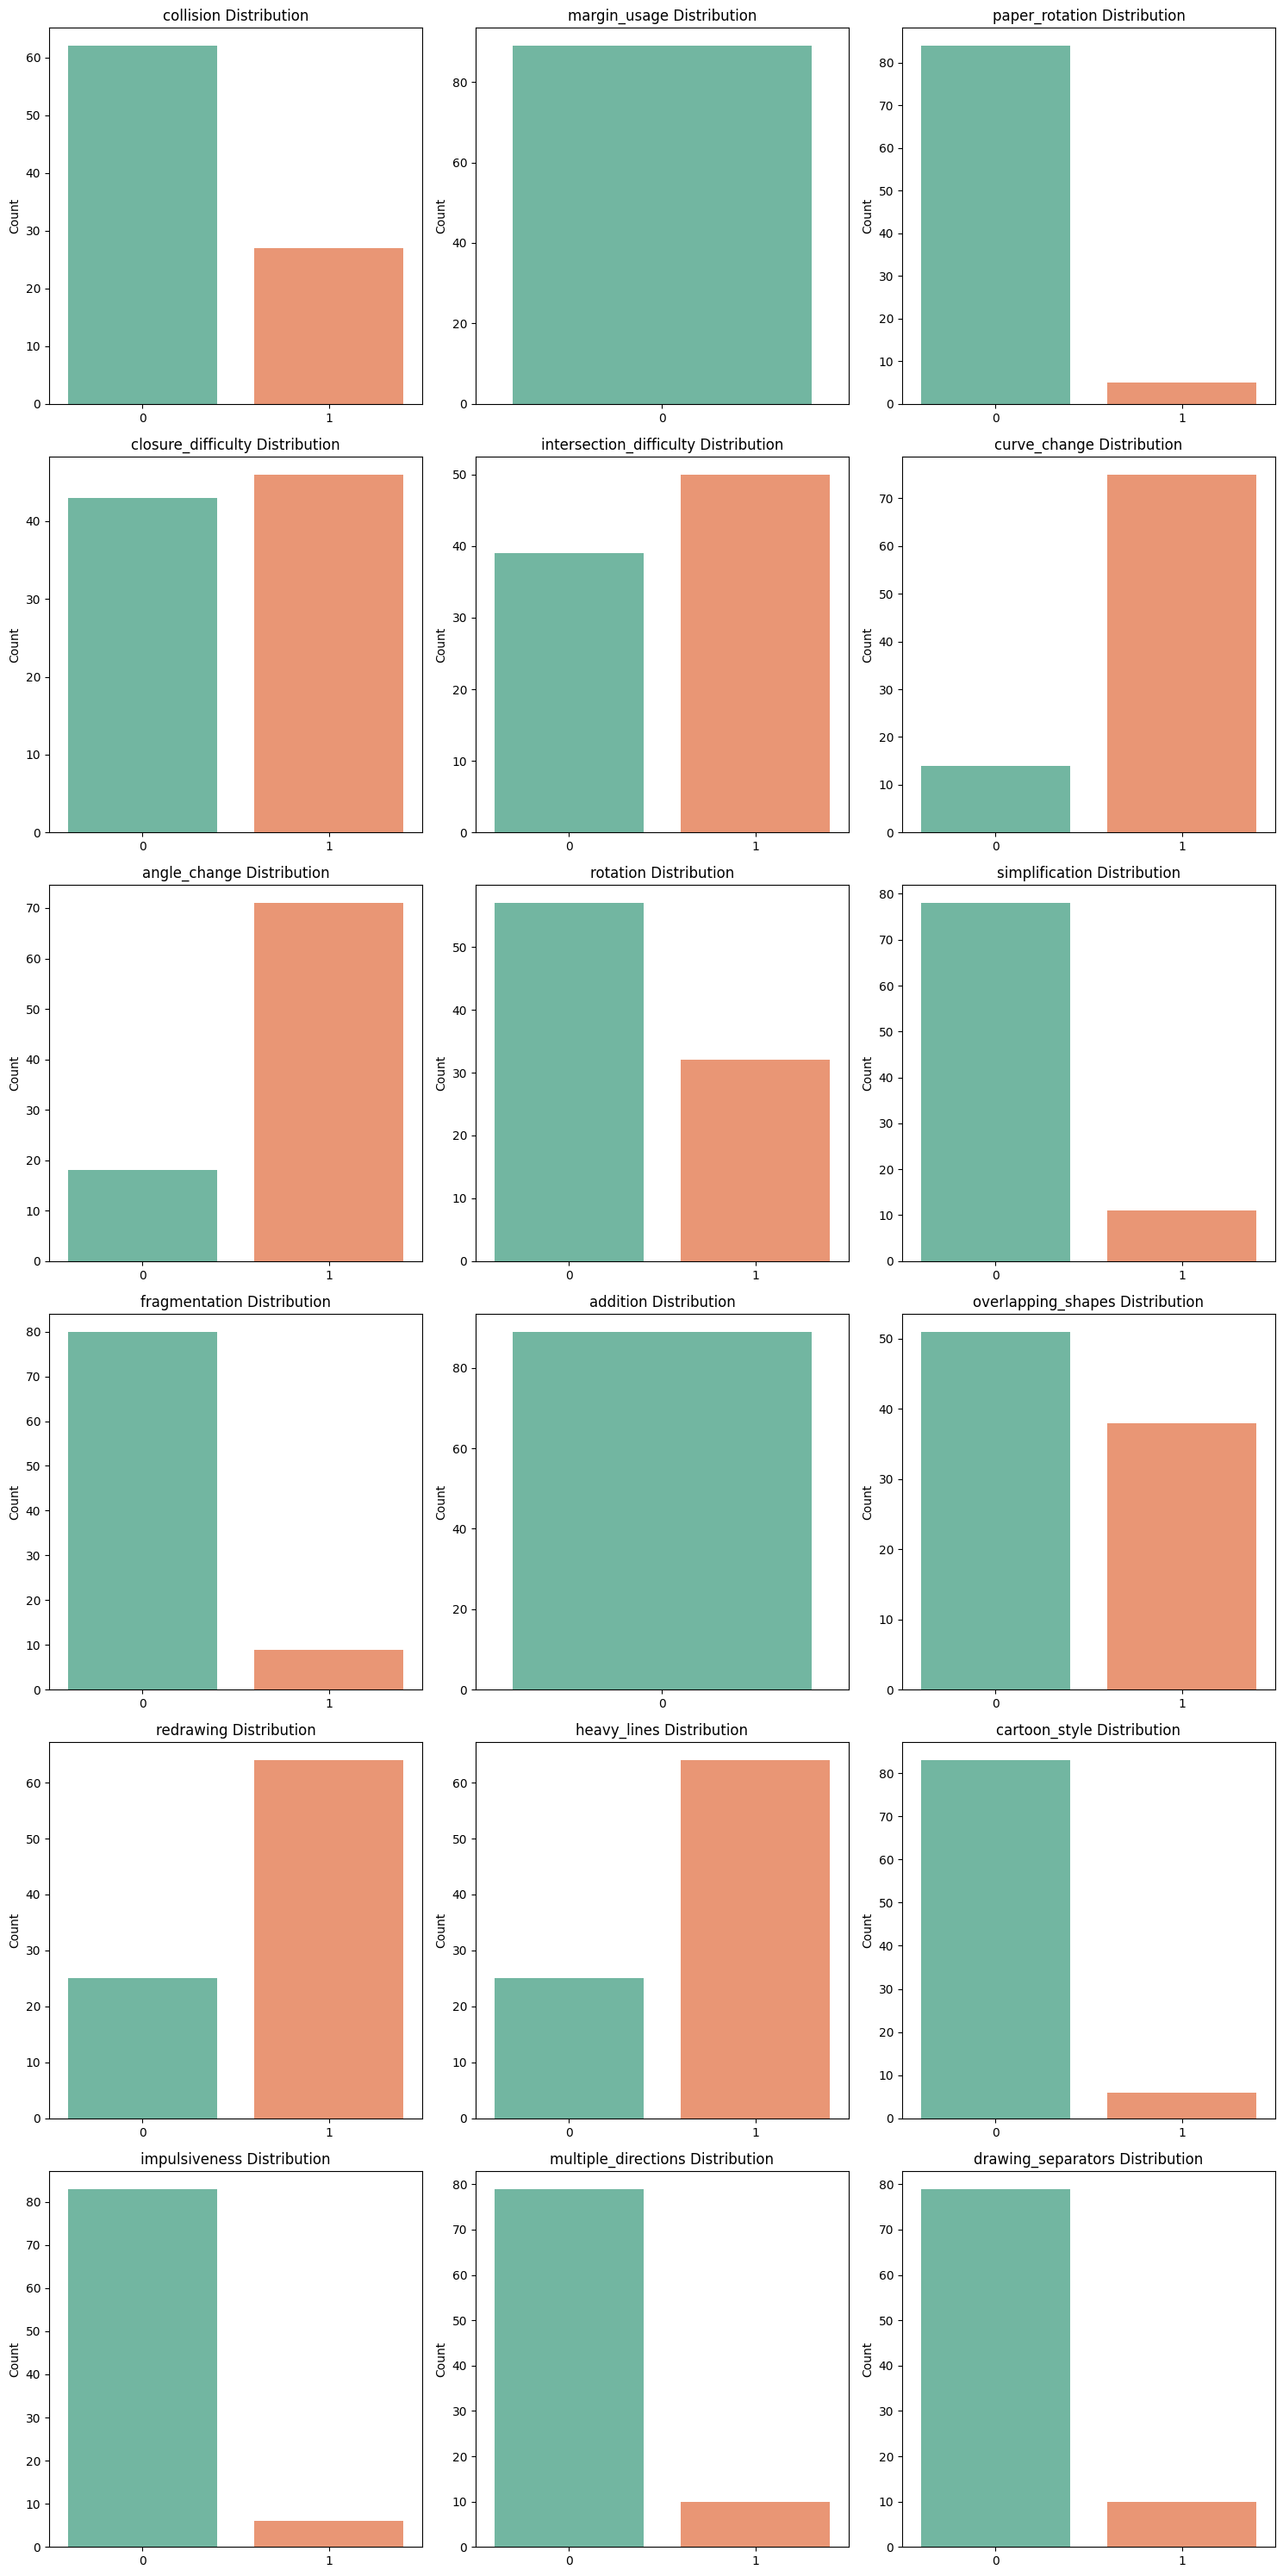

In [69]:
n_cols = 3
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.countplot(x=df[col], ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("features_distribution.png", dpi=150)
plt.show();

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


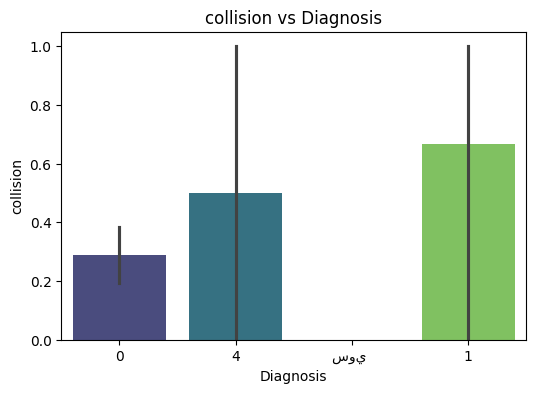

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


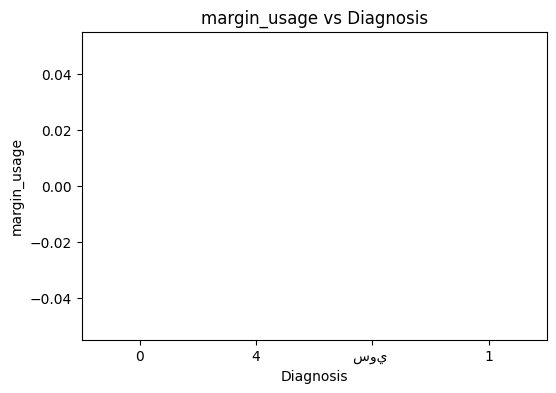

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


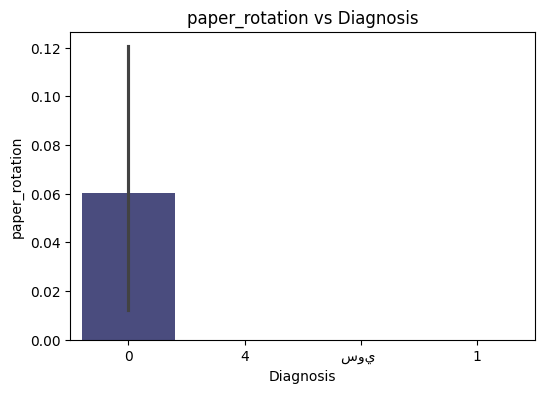

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


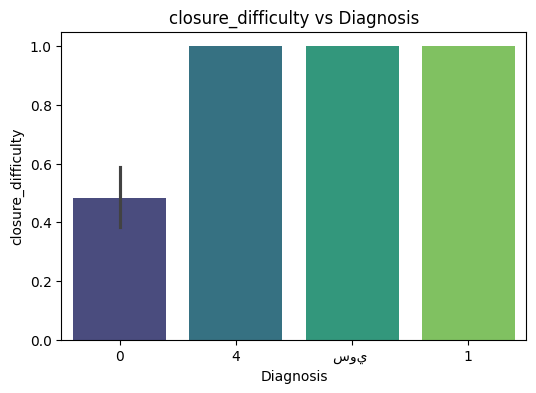

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


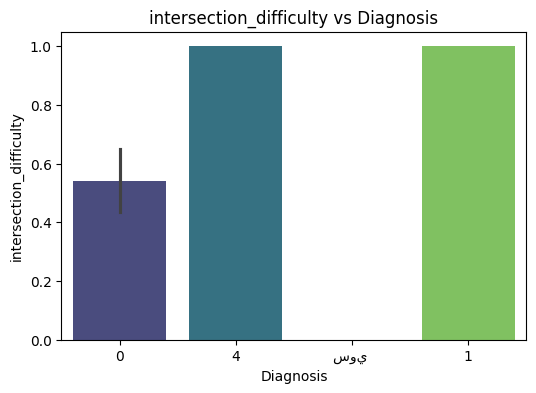

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


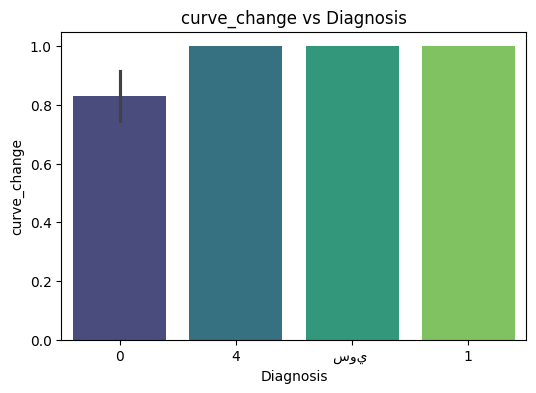

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


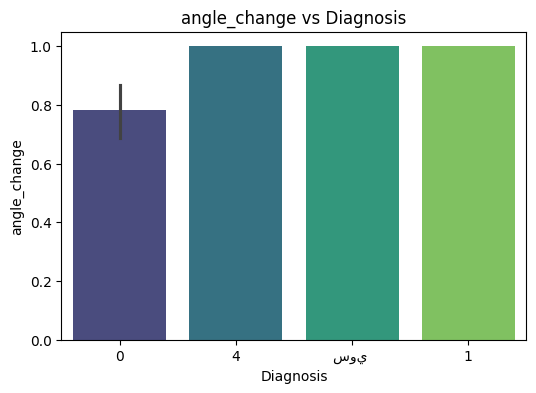

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


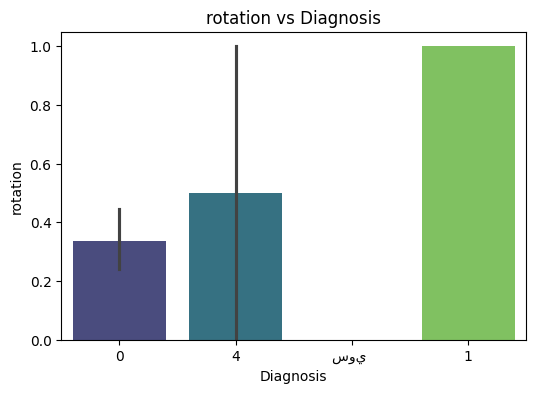

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


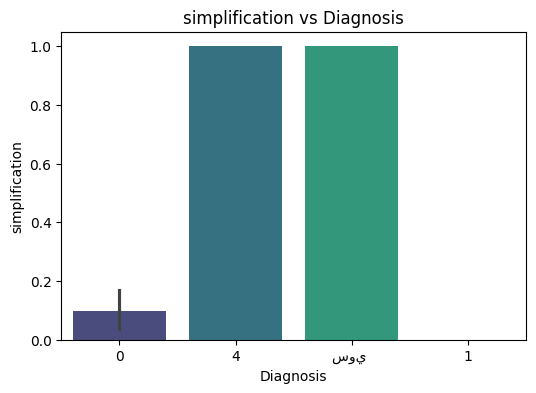

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


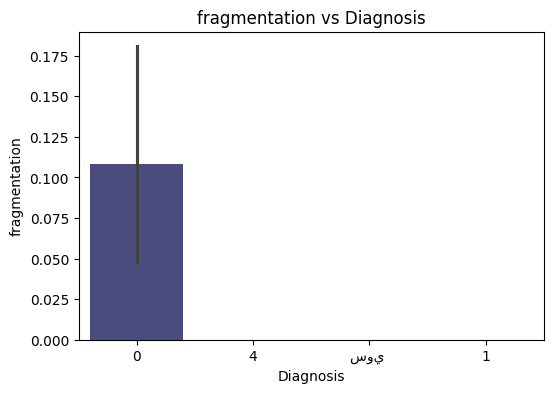

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


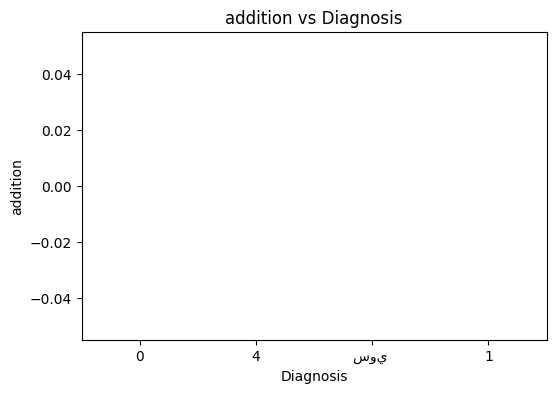

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


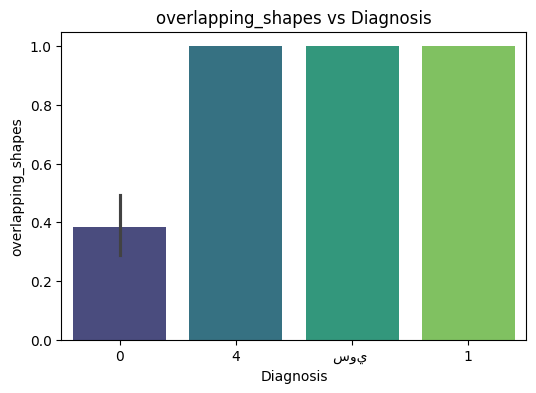

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


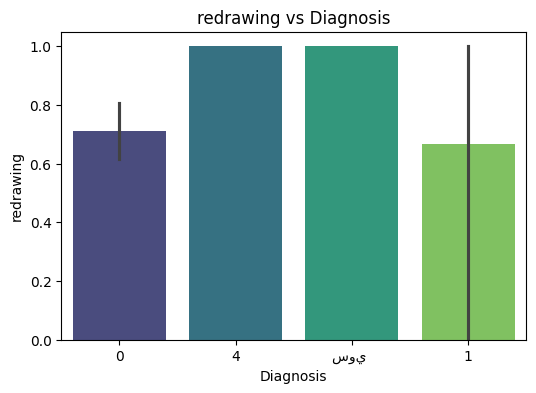

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


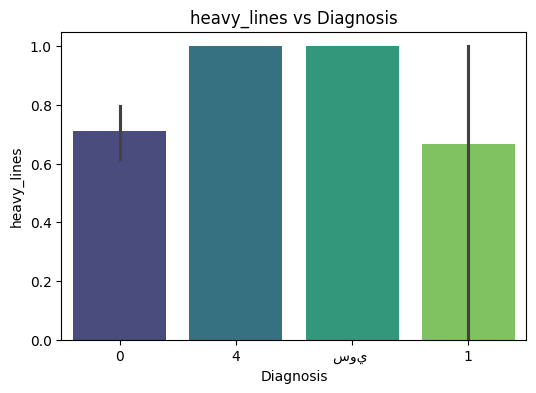

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


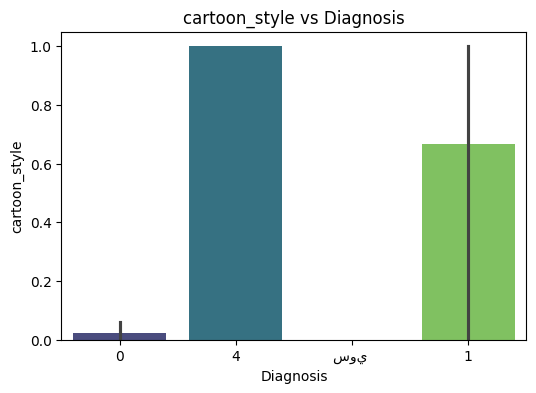

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


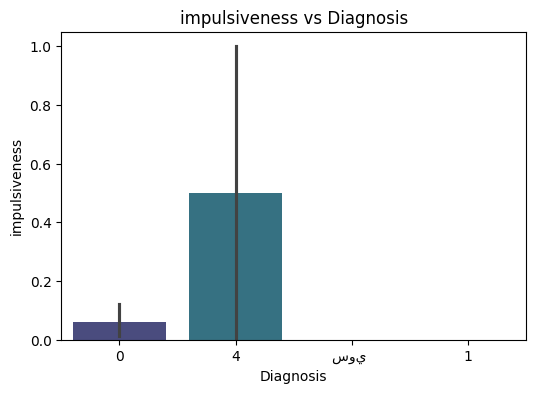

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


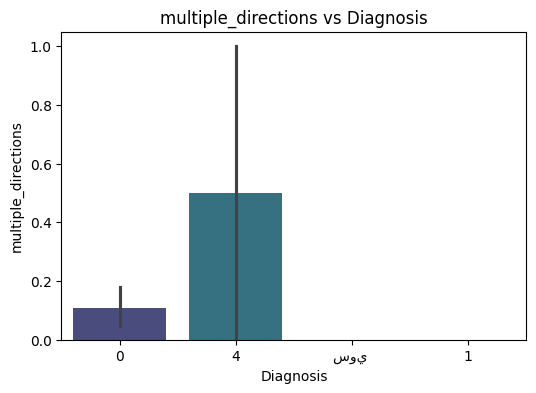

/tmp/ipykernel_7900/401511549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")


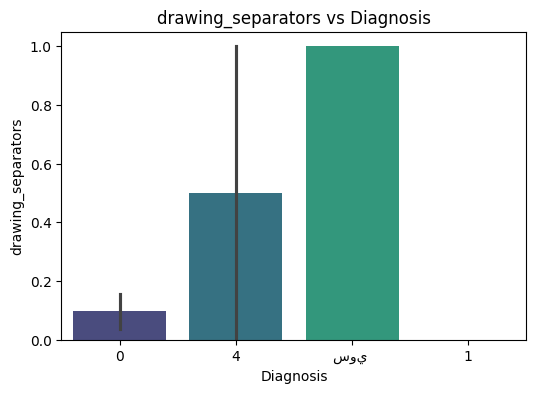

In [70]:
for col in feature_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(x=df["diagnosis"], y=df[col], palette="viridis")
    plt.title(f"{col} vs Diagnosis")
    plt.xlabel("Diagnosis")
    plt.ylabel(col)
    plt.show()

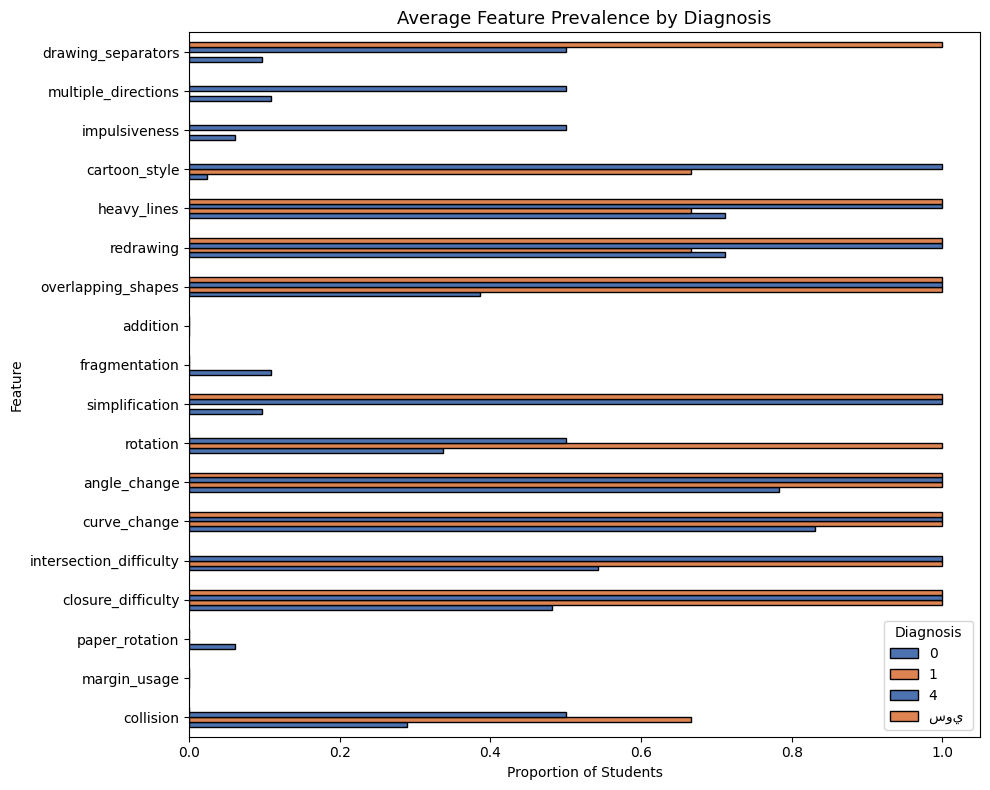

In [71]:
feature_by_diag = df.groupby("diagnosis")[feature_cols].mean().T

fig, ax = plt.subplots(figsize=(10, 8))
feature_by_diag.plot(kind="barh", ax=ax, color=["#4C72B0", "#DD8452"], edgecolor="black")
ax.set_title("Average Feature Prevalence by Diagnosis", fontsize=13)
ax.set_xlabel("Proportion of Students")
ax.set_ylabel("Feature")
ax.legend(title="Diagnosis")
plt.tight_layout()
plt.savefig("features_by_diagnosis.png", dpi=150)
plt.show()


Correlation heatmap (features only)

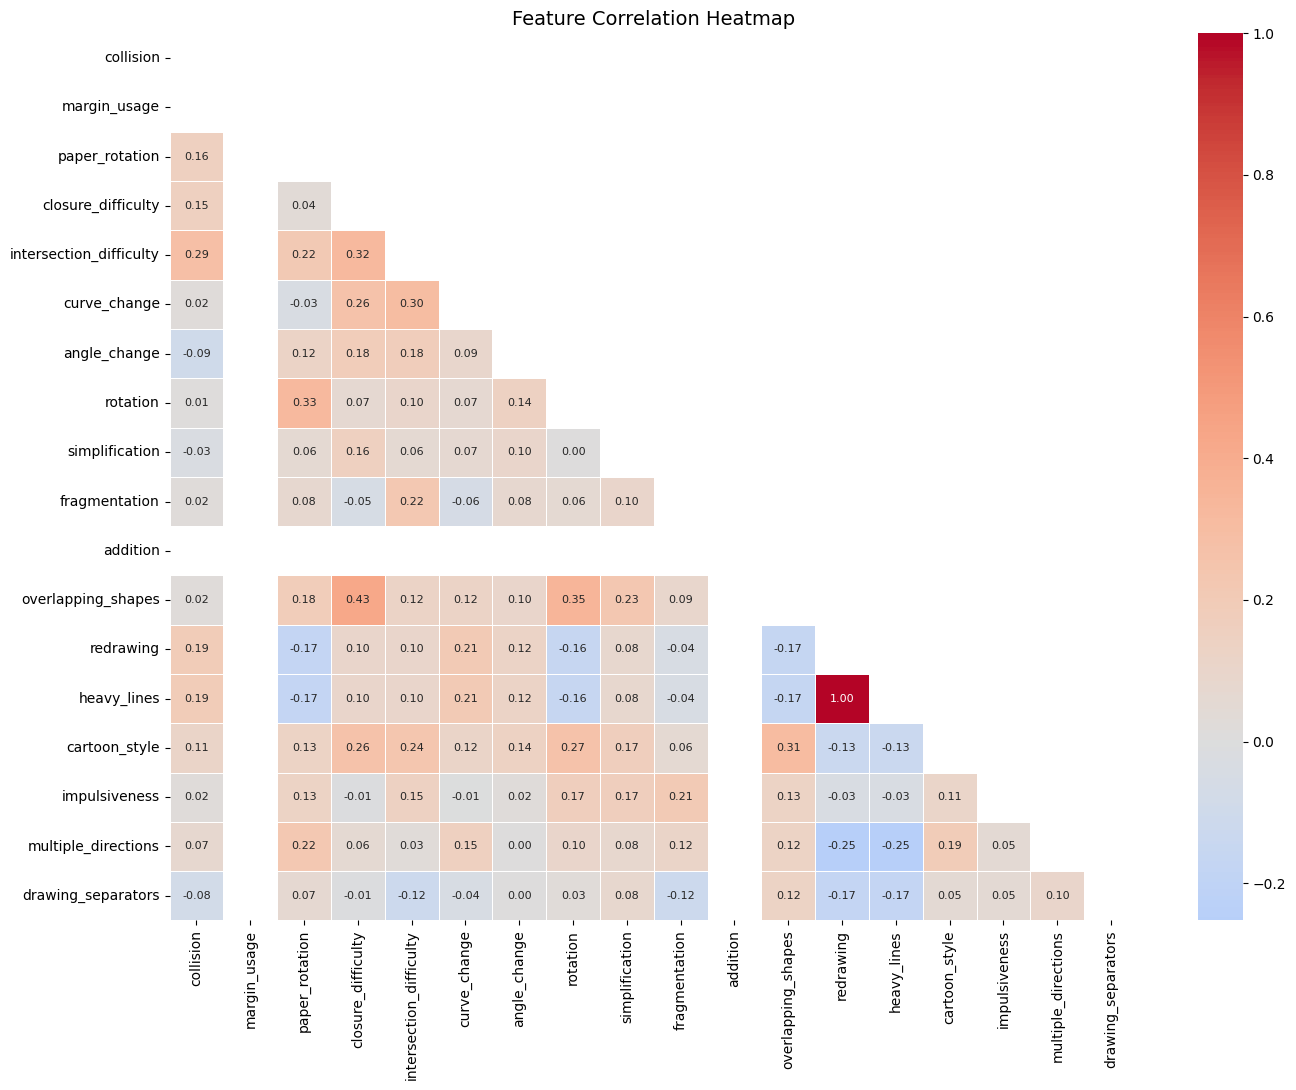

In [72]:
plt.figure(figsize=(14, 11))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("feature_correlation_heatmap.png", dpi=150)
plt.show()


Heatmap(diagnosis × feature)

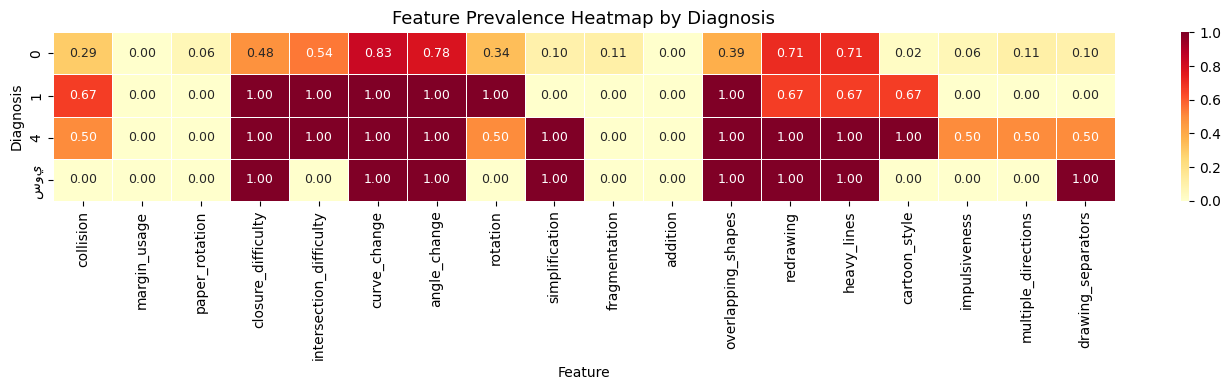

In [73]:
plt.figure(figsize=(14, 4))
sns.heatmap(feature_by_diag.T, annot=True, fmt=".2f",
            cmap="YlOrRd", linewidths=0.5, annot_kws={"size": 9})
plt.title("Feature Prevalence Heatmap by Diagnosis", fontsize=13)
plt.ylabel("Diagnosis")
plt.xlabel("Feature")
plt.tight_layout()
plt.savefig("diagnosis_feature_heatmap.png", dpi=150)
plt.show()

Age distribution by diagnosis

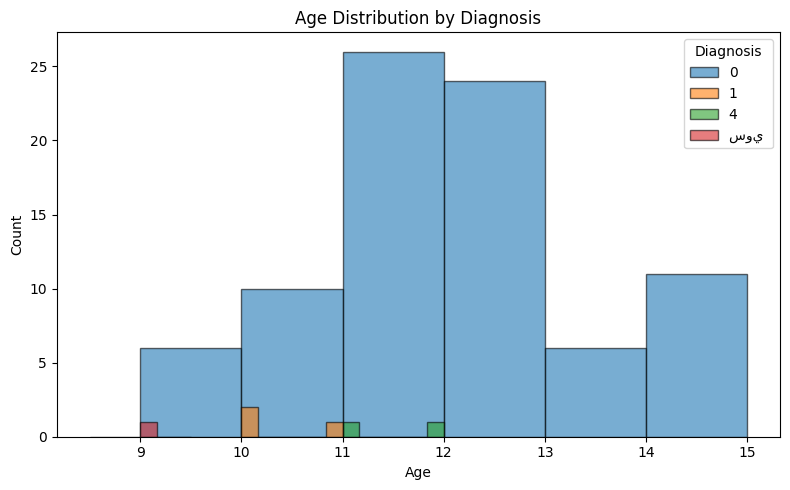

In [74]:
plt.figure(figsize=(8, 5))
for diag, grp in df.groupby("diagnosis"):
    grp["age"].plot(kind="hist", bins=6, alpha=0.6, label=str(diag), edgecolor="black")
plt.title("Age Distribution by Diagnosis")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.savefig("age_distribution_by_diagnosis.png", dpi=150)
plt.show()


Gender vs Diagnosis

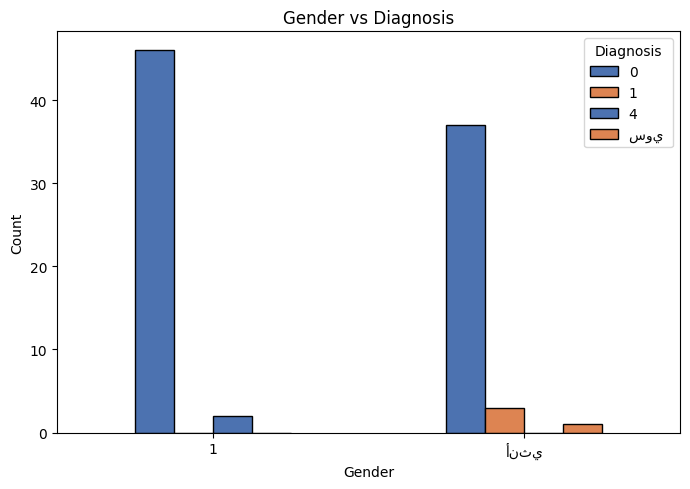

In [75]:
gender_diag = df.groupby(["gender", "diagnosis"]).size().unstack(fill_value=0)
gender_diag.plot(kind="bar", figsize=(7, 5), color=["#4C72B0", "#DD8452"], edgecolor="black")
plt.title("Gender vs Diagnosis")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.savefig("gender_vs_diagnosis.png", dpi=150)
plt.show()

Total errors per student

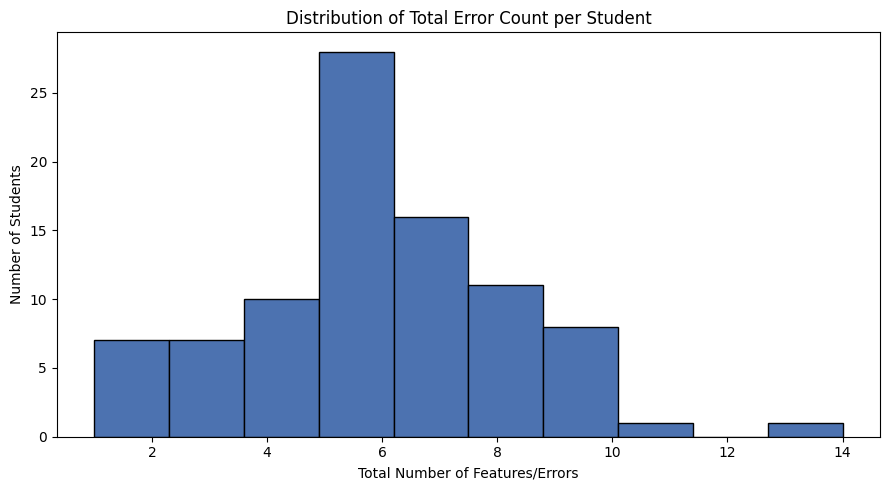

In [76]:
df["total_errors"] = df[feature_cols].sum(axis=1)

plt.figure(figsize=(9, 5))
plt.hist(df["total_errors"], bins=10, color="#4C72B0", edgecolor="black")
plt.title("Distribution of Total Error Count per Student")
plt.xlabel("Total Number of Features/Errors")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("total_errors_distribution.png", dpi=150)
plt.show()


total errors by diagnosis

<Figure size 700x500 with 0 Axes>

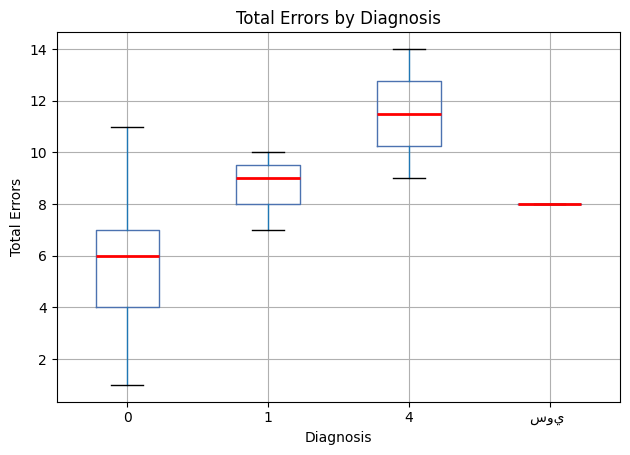

In [77]:
plt.figure(figsize=(7, 5))
df.boxplot(column="total_errors", by="diagnosis",
           boxprops=dict(color="#4C72B0"),
           medianprops=dict(color="red", linewidth=2))
plt.title("Total Errors by Diagnosis")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("Total Errors")
plt.tight_layout()
plt.savefig("total_errors_by_diagnosis.png", dpi=150)
plt.show()

Summary statistics

In [79]:

feature_freq = df[feature_cols].sum().sort_values(ascending=False)

print("\n=== Feature Frequency Summary ===")
print(feature_freq.to_string())

print("\n=== Average Features by Diagnosis ===")
print(df.groupby("diagnosis")[feature_cols].mean().round(2).to_string())

print("\n=== Total Errors by Diagnosis (mean ± std) ===")
print(df.groupby("diagnosis")["total_errors"].agg(["mean", "std", "min", "max"]).round(2))


=== Feature Frequency Summary ===
curve_change               75
angle_change               71
redrawing                  64
heavy_lines                64
intersection_difficulty    50
closure_difficulty         46
overlapping_shapes         38
rotation                   32
collision                  27
simplification             11
multiple_directions        10
drawing_separators         10
fragmentation               9
cartoon_style               6
impulsiveness               6
paper_rotation              5
margin_usage                0
addition                    0

=== Average Features by Diagnosis ===
           collision  margin_usage  paper_rotation  closure_difficulty  intersection_difficulty  curve_change  angle_change  rotation  simplification  fragmentation  addition  overlapping_shapes  redrawing  heavy_lines  cartoon_style  impulsiveness  multiple_directions  drawing_separators
diagnosis                                                                                       